# ホテリング理論による異常検知

最尤推定で学習した正規分布を正常のモデルとして使用する異常検知手法が、**ホテリング理論**（Hotelling’s T2 statistic） [Hotelling, 1931] です。ホテリング理論は、解析計算に基づく理論の明快さや、統計ライブラリによる実装のしやすさから、基礎的な異常検知アルゴリズムの一つとして広く利用されています。

ここでは以下の手順で、1変数のホテリング理論による異常検知をPythonで実装する手順を解説します。

- A. データが正規分布に従うかを判断
- B. モデルの学習
- C. 推論

なおデータセットには2章で作成したサンプルデータを使用し、入力する変数は`temp1`または`temp2`を、ターゲットとする誤報率としては0.0027を採用します。

## A. データが正規分布に従うかを判断

ホテリング理論は、データが正規分布に従うことを前提とした手法です。よってまずは、データが正規分布に従っているかを判断します。その判断のためには、以下のような方法が有効です。

- ヒストグラムによる可視化
- Q-Q プロットによる可視化
- 正規性検定

### ヒストグラムによる可視化

ヒストグラムによる可視化を実施し、その形状から正規分布かどうかを判断します。定性的とはなりますが、以下のような要素を満たせば、おおむね正規分布であると判断してよいでしょう。

- 山が一つ
- 左右対称
- 釣鐘型の分布形状
- 裾が長すぎない（外れ値が少ない）


ヒストグラムはMatplotlibを用いて以下のように描画します（2章の再掲）。

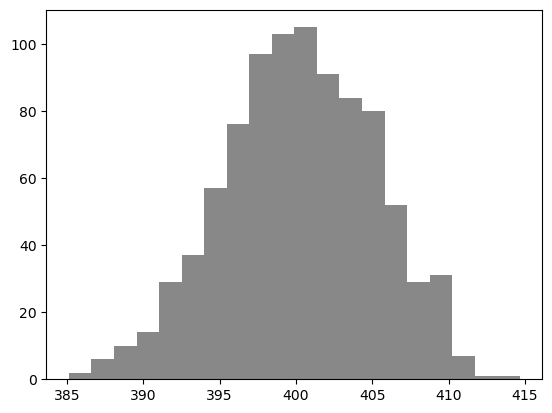

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# CSVからデータ読み込み
df = pd.read_csv("./datasets/ch2_dataset_train.csv")
df_dropna = df.dropna(subset="temp1") # 欠測値削除
df_normal = df_dropna[df_dropna["label"] == "normal"] # 正常データのみを抽出
x_train = df_normal["temp1"].to_numpy() # "temp1"列を抽出してndarrayに変換

# 変数"temp1"のヒストグラムを表示（カラーコードで色指定）
plt.hist(x=x_train, color="#888888", bins=20)
# 図を表示
plt.show()

スタージェスの公式で自動設定されるビン数では形状をうまく把握できないこともあるので、適宜ビン数を調整してください。

### Q-Qプロットによる可視化

ヒストグラムによる正規性の確認は、分析者が正規分布の形状の特徴を把握しておく必要があり、その判断には慣れが必要です。

このような属人的な、正規性をよりシンプルに判断できる可視化手法である、**Q-Qプロット**（quantile–quantile plot）が有効です。Q-Qプロットは、二つの確率分布の分位数をx軸とy軸にプロットしたグラフであり、実用上はデータと、そのデータにフィッティングした確率分布とを比較する用途でよく用いられます。データが正規分布に従うかを判断するには、以下の手順でQ-Qプロットを活用します。

1. データを昇順にソートし、分位点を求める
2. データに対して最尤推定で正規分布をフィッティングし、求めた正規分布の分位点を求める
3. 1で求めたデータの分位点を縦軸、2で求めた正規分布の分位点を横軸にとり、散布図をプロットする（この散布図をQ-Qプロットとして用いる）
4. 3で作成したQ-Qプロットがおおむね直線に沿っていれば、データが正規分布に従うとみなす

SciPyの`scipy.stats.probplot`関数を用いると、上記の1〜3の操作を自動で実施して散布図がプロットされます。以下に実装例を示します。


((array([-3.17093678e+00, -2.90366575e+00, -2.75438128e+00, -2.64902537e+00,
         -2.56678808e+00, -2.49893723e+00, -2.44094853e+00, -2.39016407e+00,
         -2.34488493e+00, -2.30395699e+00, -2.26655926e+00, -2.23208617e+00,
         -2.20007783e+00, -2.17017649e+00, -2.14209816e+00, -2.11561355e+00,
         -2.09053471e+00, -2.06670564e+00, -2.04399537e+00, -2.02229283e+00,
         -2.00150297e+00, -1.98154383e+00, -1.96234420e+00, -1.94384181e+00,
         -1.92598189e+00, -1.90871598e+00, -1.89200102e+00, -1.87579853e+00,
         -1.86007401e+00, -1.84479640e+00, -1.82993763e+00, -1.81547222e+00,
         -1.80137702e+00, -1.78763087e+00, -1.77421444e+00, -1.76110997e+00,
         -1.74830114e+00, -1.73577288e+00, -1.72351128e+00, -1.71150347e+00,
         -1.69973747e+00, -1.68820219e+00, -1.67688727e+00, -1.66578305e+00,
         -1.65488051e+00, -1.64417121e+00, -1.63364721e+00, -1.62330111e+00,
         -1.61312590e+00, -1.60311502e+00, -1.59326226e+00, -1.58356180e+00,

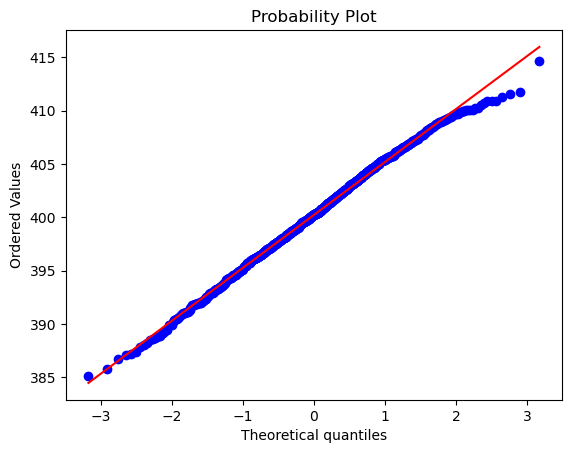

In [2]:
# コード4.27 Q-Q プロット
from scipy import stats

# Q-Qプロット
stats.probplot(x_train, dist="norm", plot=plt)

多少のずれはあるものの、Q-Qプロットがおおむね直線に沿っており、データが正規分布に従っているとみなしてよさそうです。

### 正規性検定

Q-Qプロットは正規性をヒストグラムよりもシンプルに確認することができる可視化手法ですが、その最終的な判断は分析者に委ねられるため、定性的で属人的な要素がどうしても残ってしまいます。そこでより定量的な正規性判断を行える手法として、**正規性検定**（normality test）を併用すると良いでしょう。

正規性検定とは、データが正規分布に従っているかを統計的に検定する方法全般を指します。正規性検定を行うための手法は多数存在しますが、その中でも代表的なものとして、シャピロ–ウィルク検定（Shapiro–Wilk test）とコルモゴロフ–スミルノフ検定（Kolmogorov–Smirnov test）が挙げられます。両者の原理についての解説は割愛しますが、実用上はシャピロ–ウィルク検定はサンプルサイズが⼩さいケースに、コルモゴロフ–スミルノフ検定はサンプルサイズが比較的⼤きいケースに適した手法と言われています。

SciPyにおいては、シャピロ–ウィルク検定は`scipy.stats.shapiro`関数で、コルモゴロフ–スミルノフ検定は`scipy.stats.kstest`関数を用いて実装可能です。以下に実装例を示します。

In [3]:
# コード4.28 正規性検定
import numpy as np

# Shapiro-Wilk検定
stat, p = stats.shapiro(x_train)
print("Shapiro-Wilk検定の統計量=%.3f, p値=%.3f" % (stat, p))
# Kolmogorov-Smirnov検定（平均と標準偏差を`args`引数に与える必要がある）
mean = np.mean(x_train)
std = np.std(x_train, ddof=1)
stat, p = stats.kstest(x_train, stats.norm.cdf, args=(mean, std))
print("Kolmogorov-Smirnov検定の統計量=%.3f, p値=%.3f" % (stat, p))

Shapiro-Wilk検定の統計量=0.997, p値=0.056
Kolmogorov-Smirnov検定の統計量=0.020, p値=0.838


なお、これらの検定はデータが正規分布からサンプリングされたものであるという帰無仮説を用いています。よってp 値が有意水準を下回った際に、データが正規分布に従わないこと
を結論付けられますが、上記の例のようにp値が有意水準（p値=0.05）を上回っていても、データが正規分布に従うことを裏付けられるわけではありません。あくまで目安として利用し、最終的な正規性の判断は前述したヒストグラムやQ-Qプロットと併用して行ってください。

## B. モデルの学習

学習フェーズでは、最尤推定による正規分布パラメータの推定、および異常度のしきい値算出を実施します。

1変数のホテリング理論では、サンプルサイズ$N$の大小に応じて以下のように異常度

<img src="https://latex.codecogs.com/svg.image?
a(x) = \Big(\frac{x-\hat{\mu}}{\hat{\sigma}}\Big)^2
" />

が従う確率分布を使い分けます（$\hat{\mu}$は標本平均、$\hat{\sigma}$は標本標準偏差）。

- サンプルサイズ$N$が**大きい**場合：異常度の分布は自由度1の**カイ二乗分布**に近似できる
- サンプルサイズ$N$が**小さい**場合：異常度を$\frac{N-1}{N+1}$倍した統計量は自由度$(1,N − 1)$の**F分布**に従う

カイ二乗分布とF分布の使い分けにおける$N$の明確な境界は定められていませんが、1変数においてはおおむね$N\geq 100$であれば、計算がより簡単なカイ二乗分布による近似を利用した方がよいでしょう。ここではそれぞれの場合について、Pythonでモデルの学習を実装する方法を解説します。

### サンプルサイズ$N$が大きい場合の学習の実装

サンプルサイズ$N$が大きい場合、異常度$a(x) = \Big(\frac{x-\hat{\mu}}{\hat{\sigma}}\Big)^2$が自由度1のカイ二乗分布に従うことを前提に、以下のように正規分布（正常のモデル）のパラメータ$\hat{\mu}$（コード中の`mu`）、$\hat{\sigma}$（`sigma`）および異常度のしきい値$a_{th}$（`a_th`）を求めます。

In [4]:
# コード4.29 ホテリング理論による異常検知（サンプルサイズNが⼤きい場合）の実装例（学習）
import pandas as pd
import numpy as np
from scipy import stats

###### 学習データの読み込みと前処理######
# CSVからPandas DataFrameにデータ読み込み
df = pd.read_csv("./datasets/ch2_dataset_train.csv")
# "temp1"変数に欠測があるデータを削除
df_dropna = df.dropna(subset="temp1")
# 正常データのみを抽出
df_normal = df_dropna[df_dropna["label"] == "normal"]
# "temp1"列のみ取り出してNumPyのndarray化し、学習データとする
x_train = df_normal["temp1"].to_numpy()

###### 学習ステップ1. 正常のモデルを作成する######
mu = np.mean(x_train) # 標本平均μを算出
sigma = np.std(x_train, ddof=0) # 標本標準偏差σを算出

###### 学習ステップ2. 異常を表す指標（異常度）を定義する######
# 式を定義するのみでプログラム上は処理を実施しない

###### 学習ステップ3. 異常度にしきい値を設ける######
TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）
# ⾃由度1のカイ二乗分布の累積分布関数の逆関数からしきい値算出
a_th = stats.chi2.ppf(1-TARGET_FP_RATE, df=1)

###### 学習で求めたパラメータをすべて表示######
print(f"mu={mu}")
print(f"sigma={sigma}")
print(f"a_th={a_th}")

mu=400.21552883243925
sigma=4.958226656997426
a_th=8.99986195674967


### サンプルサイズ$N$が小さい場合の学習の実装

サンプルサイズ$N$が小さい場合、異常度を$a(x) = \Big(\frac{x-\hat{\mu}}{\hat{\sigma}}\Big)^2$を$\frac{N-1}{N+1}$倍した統計量が自由度$(1,N − 1)$のF分布に従うことを前提に、以下のように正規分布（正常のモデル）のパラメータ$\hat{\mu}$（コード中の`mu`）、$\hat{\sigma}$（`sigma`）および異常度のしきい値$a_{th}$（`a_th`）を求めます。

In [5]:
# コード4.33 最尤推定の誤差を考慮したホテリング理論による異常検知の実装例（学習）

###### 学習データの読み込みと前処理######
# CSVからPandas DataFrameにデータ読み込み
df = pd.read_csv("./datasets/ch2_dataset_train.csv")
# "temp1"変数に欠測があるデータを削除
df_dropna = df.dropna(subset="temp1")
# 正常データのみを抽出
df_normal = df_dropna[df_dropna["label"] == "normal"]
# "temp1"列のみ取り出してNumPyのndarray化し、学習データとする
x_train = df_normal["temp1"].to_numpy()

###### 学習ステップ1. 正常のモデルを作成する######
mu = np.mean(x_train) # 標本平均μを算出
sigma = np.std(x_train, ddof=0) # 標本標準偏差σを算出

###### 学習ステップ2. 異常を表す指標（異常度）を定義する######
# 式を定義するのみでプログラム上は処理を実施しない

###### 学習ステップ3. 異常度にしきい値を設ける######
TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）
sample_size = len(x_train) # サンプルサイズN
# ⾃由度（1,N-1）のF分布の累積分布関数の逆関数からしきい値を算出
a_th = (sample_size+1)/(sample_size-1) \
* stats.f.ppf(1-TARGET_FP_RATE, dfn=1, dfd=sample_size-1)

###### 学習で求めたパラメータをすべて表示######
print(f"mu={mu}")
print(f"sigma={sigma}")
print(f"a_th={a_th}")

mu=400.21552883243925
sigma=4.958226656997426
a_th=9.06931691716027


カイ二乗分布を使用した場合と比べて異常度のしきい値がやや大きくなっており、誤報率を減らす方向（見逃し寄り）にしきい値が設定されることが分かります。

求めたパラメータ`mu`（標本平均$\hat{\mu}$）、`sigma`（標本標準偏差$\hat{\sigma}$）および異常度のしきい値`a_th`（$a_{th}$）は設定ファイルなどに保存して、推論フェーズで再利用します（ここでは簡単のため、得られたパラメータを推論時に直接コードに記述することとします）。

## C. 推論

学習フェーズで求めたパラメータとしきい値を用いて、推論データに対する異常度の算出と異常判定を行います。なお、異常度の分布にカイ二乗分布を用いる（サンプルサイズ$N$が大きい）場合もF分布を用いる（サンプルサイズ$N$が小さい）場合も、推論の実装方法に変化はありません。

In [6]:
# コード4.30 ホテリング理論による異常検知の実装例（推論）
###### 学習で求めたパラメータをここに記載
MU=400.21552883243925 # 標本平均μ
SIGMA=4.958226656997426 # 標本標準偏差σ
A_TH=8.99986195674967 # 異常度のしきい値

###### 推論データの読み込みと前処理######
# CSVからPandas DataFrameにデータ読み込み
df_inference = pd.read_csv("./datasets/ch2_dataset_inference.csv")

# "temp1"変数に欠測があるデータを削除
df_inference_dropna = df_inference.dropna(subset="temp1")
# "temp1"列のみ取り出してNumPyのndarray化し、推論データとする
x_inference = df_inference_dropna["temp1"].to_numpy()

###### 推論を実行######
# 異常度を算出
anomaly_scores = ((x_inference-MU)/SIGMA) ** 2
# しきい値により異常の有無を判定
pred = np.where(anomaly_scores > A_TH, "anomaly", "normal")
# 推論結果を表示
print(pred)

['normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'norm

推論データの異常度のヒストグラムとしきい値（Threshold）を重ねてプロットしてみます

/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_24037/4102425133.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inference_dropna['anomaly_score'] = anomaly_scores


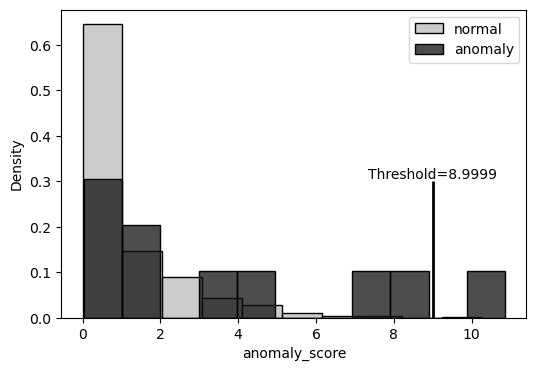

In [7]:
# 推論データの異常度のヒストグラムとしきい値を重ねてプロット（正常データと異常データで色分け）
import matplotlib.pyplot as plt
import seaborn as sns

# 異常度をDataFrameに列として追加
df_inference_dropna['anomaly_score'] = anomaly_scores
# 描画用のFigureとAxesを生成
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

# 正常データのヒストグラム描画
df_inference_norm = df_inference_dropna[df_inference_dropna['label'] == 'normal']
sns.histplot(data=df_inference_norm['anomaly_score'], binwidth=1,
             color='#bbbbbb', ax=ax,
             stat='density', label='normal')
# 異常データのヒストグラム描画
df_inference_anom = df_inference_dropna[df_inference_dropna['label'] == 'anomaly']
sns.histplot(data=df_inference_anom['anomaly_score'], binwidth=1,
             color='#111111', ax=ax,
             stat='density', label='anomaly')
# しきい値の線を描画
ax.vlines(A_TH, 0, 0.3, color='black', lw=2)
ax.text(A_TH, 0.3, f'Threshold={round(A_TH, 4)}',
        verticalalignment='bottom', horizontalalignment='center')
# 凡例を追加
ax.legend()
# グラフを表示
plt.show()

正常データと比べて異常データの異常度が高い傾向にありますが、両者の異常度分布には⼤きな重なりがあり、検出性能は限定的です。今回のしきい値（ターゲットとする誤報率=0.0027）では、異常度$>8.99$の場合に異常判定されますが、推論データ中の異常データ10件中1件のみを検出できたにすぎません。

そこで、使用する変数を`temp1`から`temp2`に変更して、再度異常度を求めてヒストグラムとしきい値を可視化します。

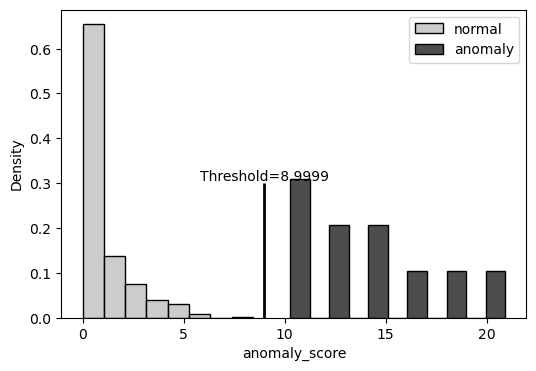

In [8]:
# "temp2"変数の推論データの異常度のヒストグラムとしきい値を重ねてプロット

###### 学習データの読み込みと前処理######
# "temp2"列のみ取り出してNumPyのndarray化し、学習データとする
x_train = df_normal["temp2"].to_numpy()

###### 学習ステップ1. 正常のモデルを作成する######
mu = np.mean(x_train) # 標本平均μを算出
sigma = np.std(x_train, ddof=0) # 標本標準偏差σを算出

###### 学習ステップ2. 異常を表す指標（異常度）を定義する######
# 式を定義するのみでプログラム上は処理を実施しない

###### 学習ステップ3. 異常度にしきい値を設ける######
TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）
sample_size = len(x_train) # サンプルサイズN
# ⾃由度1のカイ二乗分布の累積分布関数の逆関数からしきい値算出
a_th = stats.chi2.ppf(1-TARGET_FP_RATE, df=1)

###### 推論データの前処理 ######
# "temp2"変数に欠測があるデータを削除
df_inference_dropna = df_inference.dropna(subset="temp2")
# "temp2"列のみ取り出してNumPyのndarray化し、推論データとする
x_inference = df_inference_dropna["temp2"].to_numpy()

###### 推論を実行######
# 異常度を算出
anomaly_scores = ((x_inference-mu)/sigma) ** 2
# しきい値により異常の有無を判定
pred = np.where(anomaly_scores > a_th, "anomaly", "normal")
# 異常度をDataFrameに列として追加
df_inference_dropna['anomaly_score'] = anomaly_scores
# 描画用のFigureとAxesを生成
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

# 正常データのヒストグラム描画
df_inference_norm = df_inference_dropna[df_inference_dropna['label'] == 'normal']
sns.histplot(data=df_inference_norm['anomaly_score'], binwidth=1,
             color='#bbbbbb', ax=ax,
             stat='density', label='normal')
# 異常データのヒストグラム描画
df_inference_anom = df_inference_dropna[df_inference_dropna['label'] == 'anomaly']
sns.histplot(data=df_inference_anom['anomaly_score'], binwidth=1,
             color='#111111', ax=ax,
             stat='density', label='anomaly')
# しきい値の線を描画
ax.vlines(a_th, 0, 0.3, color='black', lw=2)
ax.text(a_th, 0.3, f'Threshold={round(a_th, 4)}',
        verticalalignment='bottom', horizontalalignment='center')
# 凡例を追加
ax.legend()
# グラフを表示
plt.show()

`temp2`変数を用いた場合、異常度の分布に明確な分離が見られ、10件すべての異常を検出できました。2章でのヒストグラムによる可視化でも、`temp1`より`temp2`の方が正常と異常の差異が⼤きく見えましたが、異常検知の性能においてもその印象通りの結果となりました。ここから事前にデータを可視化し、変数選択に活用することの重要性が見てとれます。

## 別解：元の変数にしきい値を設ける場合の実装法

異常度を介さずに、元の変数xに直接しきい値を設ける場合の実装法についても紹介します。この方法は、ここまで紹介した**異常度にしきい値を設ける方法と比べて、以下のようなメリット**を得ることができます。

- **ドメイン知識との親和性**：温度や湿度など、意味が明確な変数に対してしきい値を直接設定できるため、現場のエンジニアや運用担当者にも理解されやすい
- **上下各方向の制御が可能**：上限・下限に別々のしきい値を設定できるため、異常の方向性（高すぎる・低すぎる）に応じて個別に感度を制御できる

一方でこの方法は、**多変数への拡張が困難**であることや、複数のしきい値を持つことから**解釈や運用の複雑性が上がる**ことに注意が必要です。

元の変数xに直接しきい値を設ける場合は、「B. モデルの学習」「C. 推論」を、それぞれ以下のように実装します（データセットはここまでと同じものを使用し、変数は`temp2`を使用します）。

### B. モデルの学習

上で解説した異常度にしきい値を設ける場合との違いを、以下に示します。

- 学習ステップ1. 正常のモデル作成：同様
- 学習ステップ2. 異常度の定義：実施しない（異常度は使用しない）
- 学習ステップ3. しきい値の設定：正規分布（サンプルサイズ$N$が大きい場合）またはスチューデントのt分布（サンプルサイズ$N$が小さい場合）の累積分布関数に基づき、上下2方向のしきい値を算出

注意点として、上下方向の誤報率の合計が全体の誤報率となるため、片側あたりの誤報率がターゲットとする誤報率の半分と等しくなる必要があります。具体的には、下側しきい値は「累積分布関数」が、上側しきい値は「1−累積分布関数」がターゲットとする誤報率$\div 2$と等しくなるように、しきい値を求めます。

例えばサンプルサイズ$N$が大きい（正規分布に基づきしきい値を算出する）場合、以下のように実装します。

In [9]:
# コード4.31 ホテリング理論による異常検知（サンプルサイズNが⼤きい場合＆元の変数にしきい値を設ける場合）の実装例（学習）
###### 学習ステップ1. 正常のモデルを作成する######
mu = np.mean(x_train) # 標本平均μを算出
sigma = np.std(x_train, ddof=0) # 標本標準偏差σを算出

###### 学習ステップ2. 異常を表す指標（異常度）を定義する######
# 異常度は使用しない

###### 学習ステップ3. 元の変数にしきい値を設ける######
TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）
# 正規分布の累積分布関数の逆関数から下側しきい値算出（誤報率は2で割る）
th_lower = stats.norm.ppf(TARGET_FP_RATE/2, loc=mu, scale=sigma)
# 正規分布の累積分布関数の逆関数から上側しきい値算出（誤報率は2で割る）
th_upper = stats.norm.ppf(1 - TARGET_FP_RATE/2, loc=mu, scale=sigma)

###### 学習で求めたパラメータをすべて表示######
print(f"mu={mu}")
print(f"sigma={sigma}")
print(f"th_lower={th_lower}")
print(f"th_upper={th_upper}")

mu=350.2377115331434
sigma=5.103027453148678
th_lower=334.9287465805636
th_upper=365.54667648572325


また、サンプルサイズ$N$が小さい（スチューデントのt分布に基づきしきい値を算出する）場合、以下のように実装します（学習ステップ1, 2は上と同じため省略）。

In [10]:
###### 学習ステップ3. 異常度にしきい値を設ける######
TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）
sample_size = len(x_train) # サンプルサイズN
# ⾃由度N-1のt分布の累積分布関数の逆関数から下側しきい値算出（誤報率は2で割る）
th_lower = mu + sigma * np.sqrt((sample_size+1)/(sample_size-1)) \
* stats.t.ppf(TARGET_FP_RATE/2, df=sample_size-1)
# ⾃由度N-1のの累積分布関数の逆関数から上側しきい値算出（誤報率は2で割る）
th_upper = mu + sigma * np.sqrt((sample_size+1)/(sample_size-1)) \
* stats.t.ppf(1 - TARGET_FP_RATE/2, df=sample_size-1)

### 推論

異常度にしきい値を設ける場合との違いは、上下両方向に対してそれぞれしきい値を設定する点です。

In [11]:
# コード4.32 ホテリング理論による異常検知（元の変数にしきい値を設ける場合）の実装例（推論）
###### 学習したパラメータをここに記載
MU=350.25979508398035 # 標本平均μ
SIGMA=5.1071103392810135 # 標本標準偏差σ
TH_LOWER=334.88478496483145 # 下側しきい値
TH_UPPER=365.63480520312925 # 上側しきい値

###### 推論を実行######
# しきい値により異常の有無を判定（上下両方向に判定）
pred = np.where((x_inference < TH_LOWER) | (x_inference > TH_UPPER),
"anomaly", "normal")
# 推論結果を表示
print(pred)

['normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'norm

推論データの元の変数（`temp2`）のヒストグラムとしきい値（Threshold）を重ねてプロットしてみます

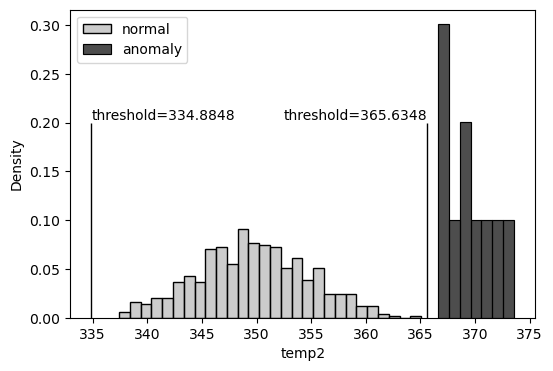

In [12]:
# 描画用のFigureとAxesを生成
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

# 正常データのヒストグラム描画
df_inference_norm = df_inference_dropna[df_inference_dropna['label'] == 'normal']
sns.histplot(data=df_inference_norm['temp2'], binwidth=1,
             color='#bbbbbb', ax=ax,
             stat='density', label='normal')
# 異常データのヒストグラム描画
df_inference_anom = df_inference_dropna[df_inference_dropna['label'] == 'anomaly']
sns.histplot(data=df_inference_anom['temp2'], binwidth=1,
             color='#111111', ax=ax,
             stat='density', label='anomaly')
# しきい値の線を描画
ax.vlines(TH_LOWER, 0, 0.2, color='black', lw=1)
ax.text(TH_LOWER, 0.2, f'threshold={round(TH_LOWER, 4)}',
        verticalalignment='bottom', horizontalalignment='left')
ax.vlines(TH_UPPER, 0, 0.2, color='black', lw=1)
ax.text(TH_UPPER, 0.2, f'threshold={round(TH_UPPER, 4)}',
        verticalalignment='bottom', horizontalalignment='right')
# 凡例を追加
ax.legend()

plt.show()

正常データの分布中心から見て、上下両方向にしきい値が引かれていることが分かります。今回のデータでは異常データが上方向（変数`temp2`が大きくなる方向）のみに偏在しているため、上側のしきい値のみが機能しますが、下方向に変化した異常データは下側のしきい値で検出されます。